In [153]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Refinement
Fonction qui va permettre de refine le topolical graphe initial, avec marge d'erreur de 2px

In [ ]:
from skimage import io
from meta import ROOT_DIR
import matplotlib.pyplot as plt

from bez.topo_graph import extract_topology_from_skeleton, extract_simple_topology_from_skeleton, image_to_skeleton
from bez.refinement import  refine
from bez.hypergraph import HyperGraph
from bez.global_optim import optimisation
from bez.viz import visualize_topo

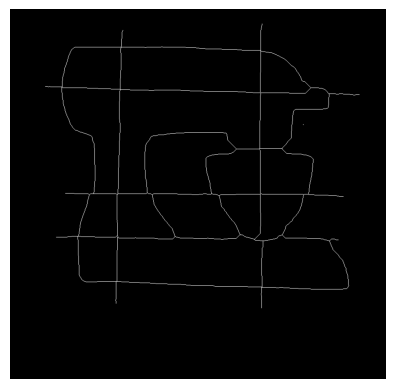

In [155]:
# Skeleton extraction
img = io.imread(ROOT_DIR /"data/original_paper/figure_2/input.png") # [100:250, 600:780, :]

skeletone, thikness = image_to_skeleton(img)
plt.imshow(skeletone, cmap="gray")
plt.axis("off")
plt.show()


In [156]:
topo_graph = extract_simple_topology_from_skeleton(skeletone)
topo_graph_ = extract_topology_from_skeleton(skeletone)
refined = refine(topo_graph)

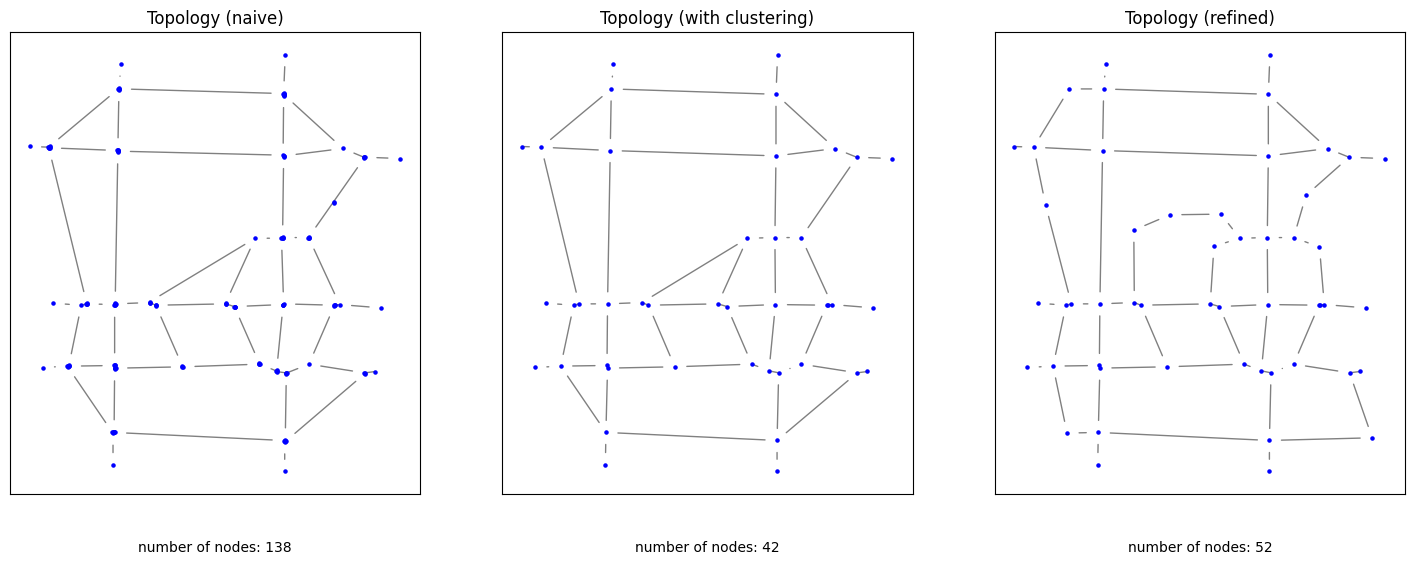

In [157]:
plt.figure(figsize=(18, 6))

ax = plt.subplot(1, 3, 1)
visualize_topo(topo_graph_)
plt.title("Topology (naive)")
ax.text(.5,-0.1,f"number of nodes: {len(topo_graph_.nodes())}", fontsize=10, ha='center', va='top', transform=ax.transAxes)

ax = plt.subplot(1, 3, 2)
visualize_topo(topo_graph)
plt.title("Topology (with clustering)")
ax.text(.5,-0.1,f"number of nodes: {len(topo_graph.nodes())}", fontsize=10, ha='center', va='top', transform=ax.transAxes)

ax = plt.subplot(1, 3, 3)
visualize_topo(refined)
plt.title("Topology (refined)")
ax.text(.5,-0.1,f"number of nodes: {len(refined.nodes())}", fontsize=10, ha='center', va='top', transform=ax.transAxes)

plt.show()

In [158]:
hyper = HyperGraph(refined)

# param
lam = 0.8
temp = 0.5
t_min = 0.05
mu = 0.3
t_decrease = 0.999 ** (1/len(refined.nodes))

In [159]:
error = optimisation(hyper, lam=lam, mu=mu, temp=temp, t_decrease=t_decrease, t_min=t_min)


100%|██████████| 119674/119674 [00:47<00:00, 2528.45it/s]


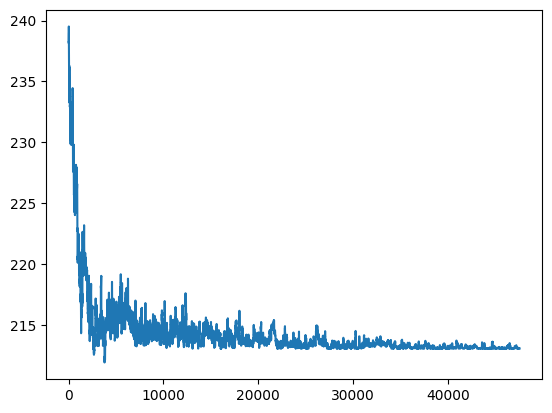

In [160]:
plt.plot(range(len(error)), error)

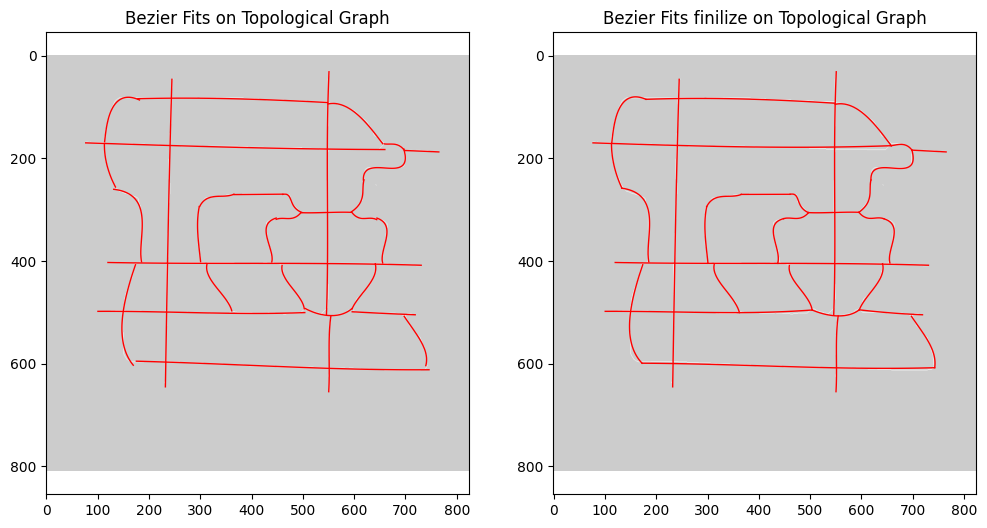

In [161]:
hyper.fit_beziers()

plt.figure(figsize=(12, 6))
# Superpose l'image originale

ax = plt.subplot(1, 2, 1)
plt.imshow(skeletone, cmap="gray", alpha=0.2)
hyper.visualize_fiting()
plt.axis("equal")
plt.title("Bezier Fits on Topological Graph")

hyper.finition()

ax = plt.subplot(1, 2, 2)
plt.imshow(skeletone, cmap="gray", alpha=0.2)
hyper.visualize_fiting()
plt.axis("equal")
plt.title("Bezier Fits finilize on Topological Graph")

plt.show()